In [19]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import superstats as sup
import bayesflow as bf
import numpy as np
from numba import njit, prange
import pandas as pd
from typing import Dict

In [2]:
NUM_STEPS = 300

## Context

In [3]:
CONTEXT_SPECS = pd.read_csv(
    "data/context_summary_exp1.csv"
).to_numpy(dtype=np.float32)

In [4]:
@njit
def generate_context(num_steps: int) -> Dict:
    # Determine the number of trials in one full context repetition
    total = 0
    for i in range(CONTEXT_SPECS.shape[0]):
        total += int(CONTEXT_SPECS[i, 4])

    # Construct one complete context
    base = np.empty(
        (total, 4),
        dtype=np.float32,
    )

    row = 0

    for i in range(CONTEXT_SPECS.shape[0]):
        stim = CONTEXT_SPECS[i, 0]
        iv = CONTEXT_SPECS[i, 1]
        val = CONTEXT_SPECS[i, 2] * 4
        corr = CONTEXT_SPECS[i, 3]
        nrep = int(CONTEXT_SPECS[i, 4])

        for _ in range(nrep):
            base[row, 0] = stim
            base[row, 1] = iv
            base[row, 2] = val
            base[row, 3] = corr
            row += 1

    # Output arrays
    stimulus = np.empty(num_steps, dtype=np.float32)
    iv = np.empty(num_steps, dtype=np.float32)
    value = np.empty(num_steps, dtype=np.float32)
    correct = np.empty(num_steps, dtype=np.float32)

    output_row = 0

    # Repeat and reshuffle the base context until num_steps is reached
    while output_row < num_steps:
        indices = np.arange(total)

        # Fisher–Yates shuffle
        for i in range(total - 1, 0, -1):
            j = int(np.random.random() * (i + 1))

            tmp = indices[i]
            indices[i] = indices[j]
            indices[j] = tmp

        remaining = num_steps - output_row
        num_to_copy = min(total, remaining)

        for i in range(num_to_copy):
            source_row = indices[i]

            stimulus[output_row] = base[source_row, 0]
            iv[output_row] = base[source_row, 1]
            value[output_row] = base[source_row, 2]
            correct[output_row] = base[source_row, 3]

            output_row += 1

    return {
        "stimulus": stimulus,
        "num_iv": iv,
        "validity": value,
        "correct_resp": correct,
    }

In [5]:
context_simulator = sup.ContextSimulator(
    simulator=generate_context,
    is_batched=False
)

## Simulator

In [6]:
@njit(fastmath=True)
def sample_ddm_trial(
    v: float,
    a: float,
    bias: float,
    tau: float,
    dt: float = 0.001,
    s: float = 1.0,
    max_iter: int = 100000
) -> np.ndarray:
    n_iter = 0
    x = a * bias
    c = s * np.sqrt(dt)
    while x > 0 and x < a and n_iter < max_iter:
        x += v*dt + c * np.random.randn()
        n_iter += 1
    rt = n_iter * dt + tau
    resp = 0 if x <= 0 else 1
    return np.array([rt, resp], dtype=np.float32)


@njit(parallel=True, fastmath=True)
def sample_dynamic_ddm(
    v0_1: np.ndarray,
    v0_2: np.ndarray,
    v0_3: np.ndarray,
    v0_4: np.ndarray,
    dv_1: np.ndarray,
    dv_2: np.ndarray,
    dv_3: np.ndarray,
    dv_4: np.ndarray,
    a: np.ndarray,
    tau: np.ndarray,
    bias: np.ndarray,
    stimulus: np.ndarray,
    validity: np.ndarray,
    correct_resp: np.ndarray,
    dt: float = 0.001,
    s: float = 1.0,
    max_iter: int = 100000
) -> np.ndarray:
    num_steps = v0_1.shape[0]
    response_time = np.empty(num_steps, dtype=np.float32)
    choice = np.empty(num_steps, dtype=np.float32)

    v_intercepts = np.stack(
        (v0_1, v0_2, v0_3, v0_4),
        axis=-1,
    )

    v_slopes = np.stack(
        (dv_1, dv_2, dv_3, dv_4),
        axis=-1,
    )

    for i in prange(num_steps):
        sign = 1.0 if correct_resp[i] == 1 else -1.0
        current_intercept = v_intercepts[i, int(stimulus[i])]
        current_slope = v_slopes[i, int(stimulus[i])]
        drift = sign * (current_intercept + current_slope * validity[i])
        
        response_time[i], choice[i] = sample_ddm_trial(
            drift, a[i], bias[i], tau[i],
            dt=dt, s=s, max_iter=max_iter
        )
        
    return {"response_time": response_time, "choice": choice}

In [14]:
formula = sup.Formula([
    "tau = tau_0 + b_tau * num_iv",
])

prior = sup.JointPrior(
    v0_1=sup.Prior("halfnormal", loc=0.0, scale=1.0),
    v0_2=sup.Prior("halfnormal", loc=0.0, scale=1.0),
    v0_3=sup.Prior("halfnormal", loc=0.0, scale=1.0),
    v0_4=sup.Prior("halfnormal", loc=0.0, scale=1.0),
    dv_1=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.1),
    ),
    dv_2=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.1),
    ),
    dv_3=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.1),
    ),
    dv_4=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.1),
    ),
    a=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.1),
    ),
    tau_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=0.75),
        sigma=sup.Prior("halfnormal", scale=0.075),
    ),
    b_tau=sup.Prior("halfnormal", scale=0.2),
    bias=0.5,
    p_missing=sup.Prior("beta", a=1.5, b=25.0),
)

In [15]:
missing_process = sup.simulation.RandomMissingProcess(
    missing_value=-1,
)

model = sup.Model(
    prior=prior,
    simulator=sample_dynamic_ddm,
    latent_link_function={
        'dv_1': sup.LinkFunction(bounds=(0.0, 4.0)),
        'dv_2': sup.LinkFunction(bounds=(0.0, 4.0)),
        'dv_3': sup.LinkFunction(bounds=(0.0, 4.0)),
        'dv_4': sup.LinkFunction(bounds=(0.0, 4.0)),
        'a': sup.LinkFunction(bounds=(0.0, 6.0)),
    }, 
    formula_link_function={
        'tau': sup.LinkFunction(bounds=(0.0, 2.0)),
    }, 
    formula=formula,
    context_simulator=context_simulator,
    design_context=('num_iv',),
    simulator_context=('stimulus', 'validity', 'correct_resp'),
    missing=missing_process,
)

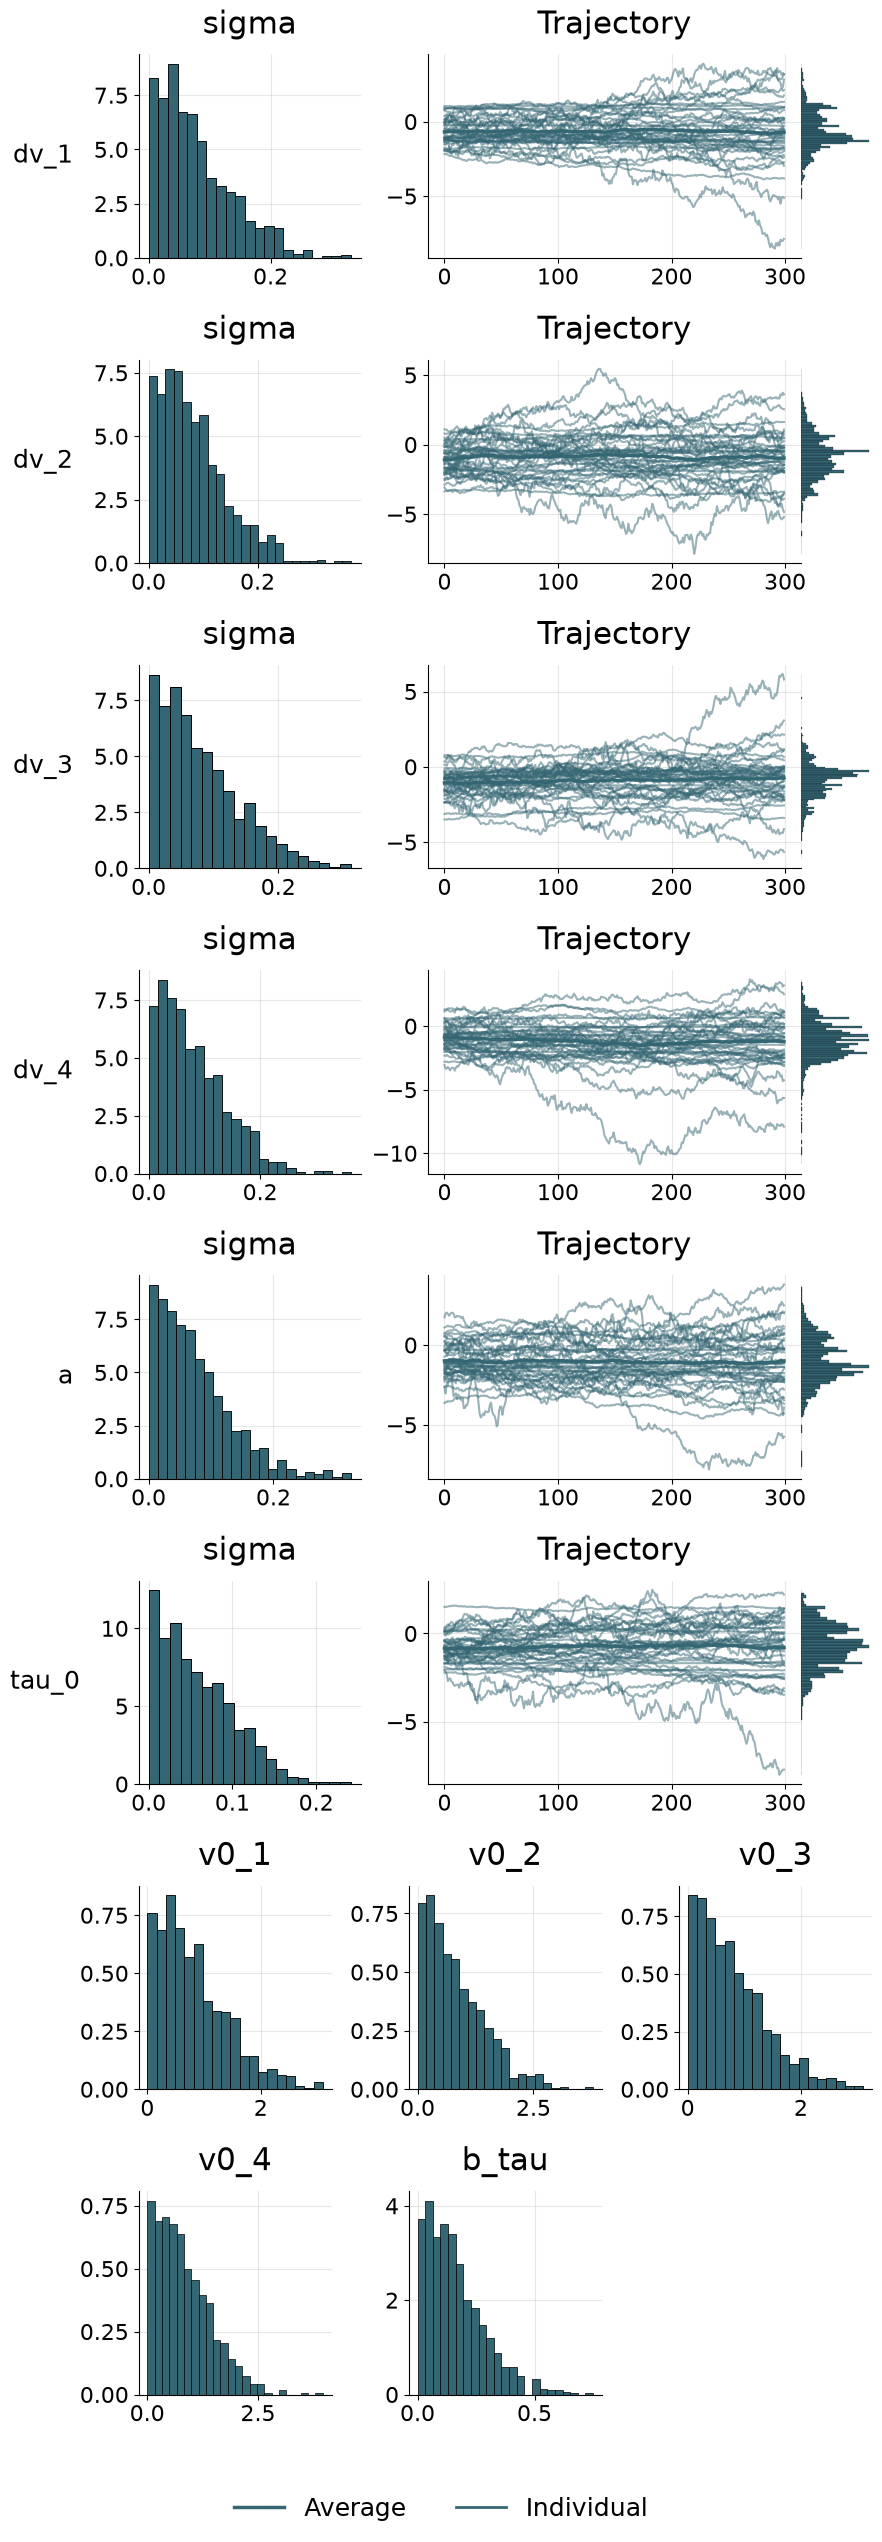

In [16]:
fig = model.plot_joint_prior(num_steps=NUM_STEPS, num_trajectories=40)

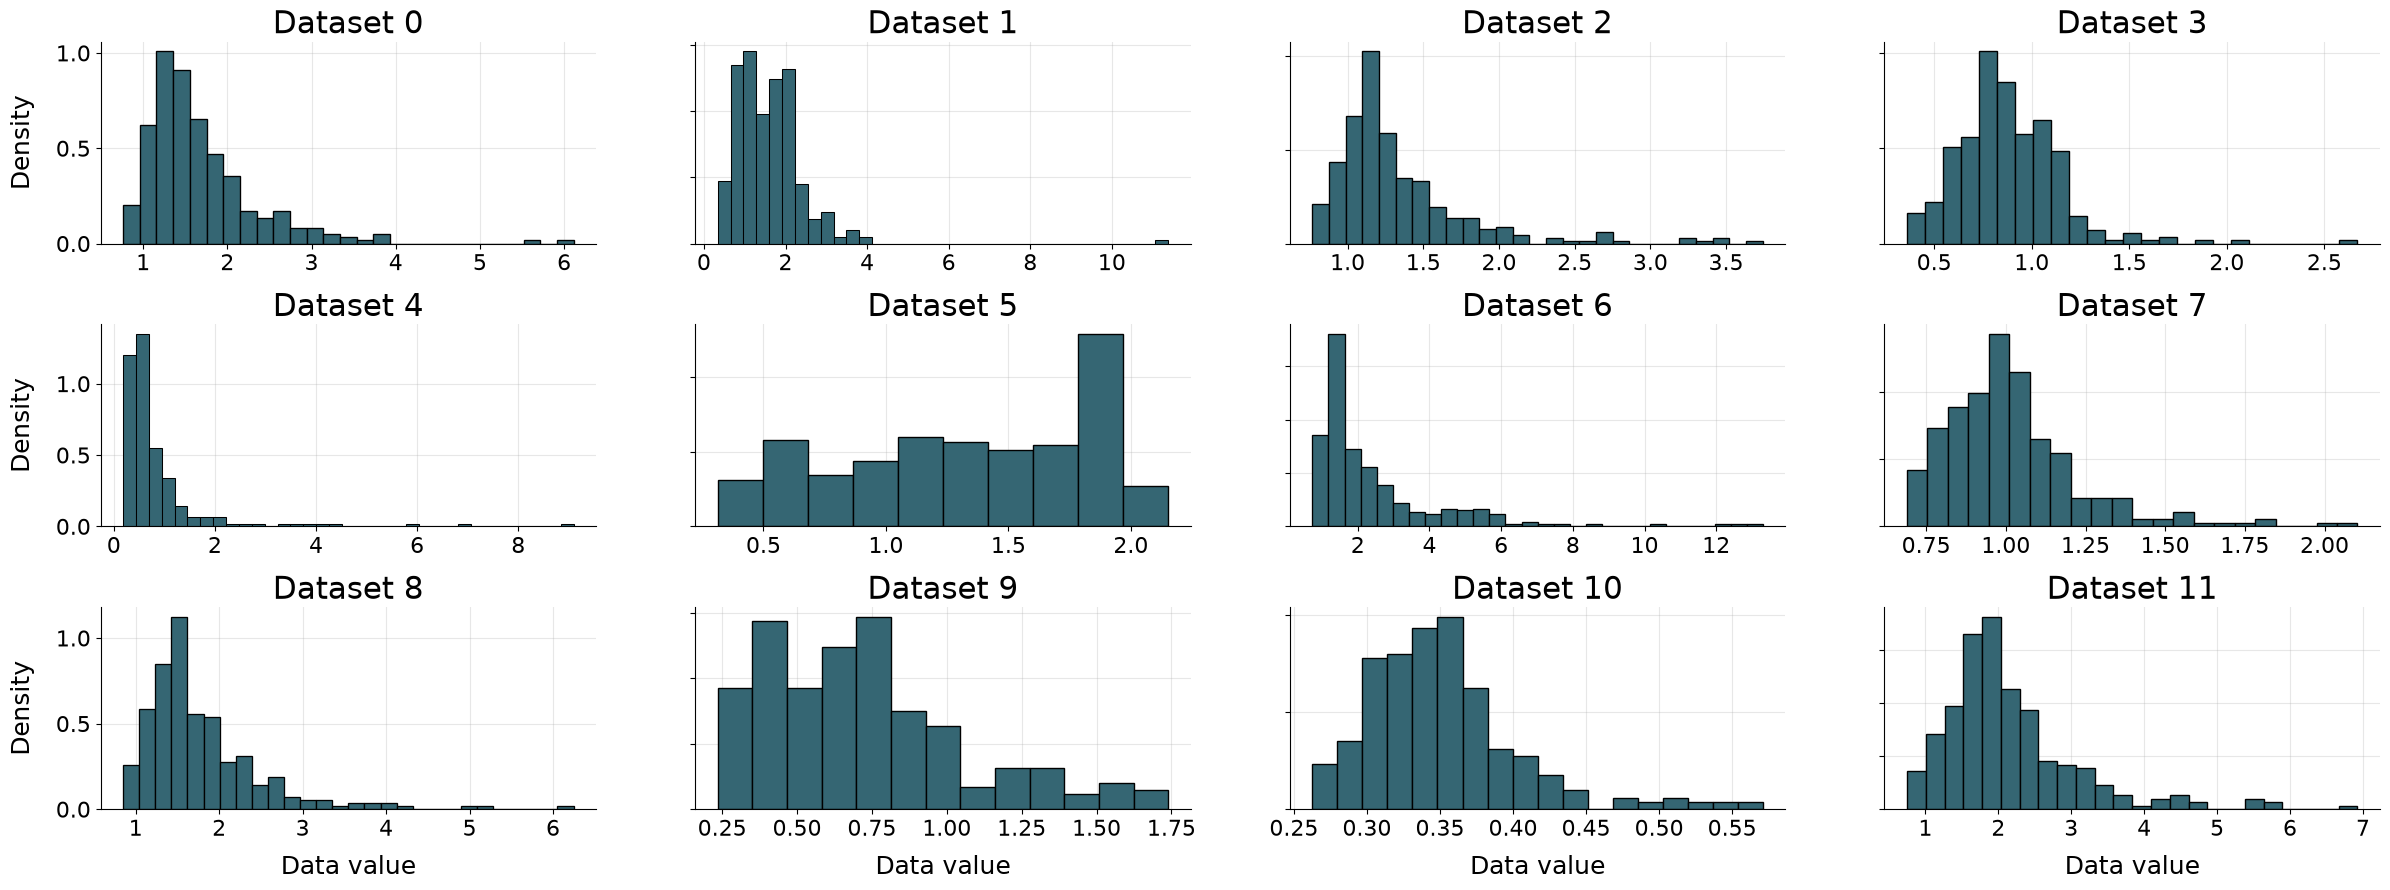

In [17]:
fig = model.plot_push_forward(
    batch_size=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist"
)

## Approximator Training

In [ ]:
workflow = sup.Workflow(
    model=model,
    approximator="marginal",
    mode="smoothing",
    checkpoint_filepath="checkpoints/attitude_study_v1"
)

In [ ]:
train_data = model.sample(
    batch_size=50_000,
    num_steps=NUM_STEPS
)

val_data = model.sample(
    batch_size=200,
    num_steps=NUM_STEPS
)

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=val_data,
    epochs=50,
    batch_size=32
)